# Análise Completa de Trajetórias de Clusters por Usuário

Pipeline completo:
1. Leitura do CSV `user_topic_cluster_labels_umap_order1.csv`
2. Matriz usuário×assignment (a1..a7)
3. Sankey agregado (colunas fixas por tópico, clusters ordenados)
4. Distância Hamming mascarada
5. Seleção de K por **Silhouette**
6. Agglomerative Clustering + dendrograma
7. Heatmap com grupos no eixo Y e separadores
8. UMAP (one-hot) colorido por grupo


In [2]:
# =======================
# 0) Configurações
# =======================
from pathlib import Path
CSV_PATH = Path("./da_artifacts/user_topic_cluster_labels_umap_order2.csv")
TOPIC_ORDER = [f"a{i}" for i in range(1, 8)]  # a1..a7
LINKAGE = "average"
RANDOM_STATE = 42
OUT_DIR = Path("./trajetory")
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# =======================
# 1) Imports e helpers
# =======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from collections import Counter
import warnings

try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

def warn_file_absent(path: Path):
    if not path.exists():
        print(f"⚠️ Arquivo não encontrado: {path.resolve()} — usando dataset de exemplo.")
        return True
    return False


/opt/homebrew/Caskroom/miniconda/base/envs/studychat/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# =======================
# 2) Leitura do CSV e preparação
# =======================
if warn_file_absent(CSV_PATH):
    df = pd.DataFrame({
        "userId": ["u1","u1","u1","u2","u2","u2","u3","u3","u3"],
        "topic":  ["a1","a2","a3","a1","a2","a3","a1","a2","a3"],
        "cluster":[0,1,2,0,0,1,3,3,2],
    })
else:
    df = pd.read_csv(CSV_PATH)

df.columns = [c.strip() for c in df.columns]
df["topic"] = df["topic"].astype(str).str.strip().str.lower()
df = df[df["topic"].isin(TOPIC_ORDER)].copy()
df["topic"] = pd.Categorical(df["topic"], categories=TOPIC_ORDER, ordered=True)
df = df.sort_values(["userId", "topic"]).reset_index(drop=True)

display(df.head(10))
print(f"N usuários = {df['userId'].nunique()}, N registros = {len(df)}")


,userId,topic,cluster
0,011bb520-7041-704f-b3e7-ab5c43dd3950,a1,0
1,011bb520-7041-704f-b3e7-ab5c43dd3950,a2,5
2,011bb520-7041-704f-b3e7-ab5c43dd3950,a4,3
3,011bb520-7041-704f-b3e7-ab5c43dd3950,a5,3
4,011bb520-7041-704f-b3e7-ab5c43dd3950,a6,4
5,011bb520-7041-704f-b3e7-ab5c43dd3950,a7,4
6,011bd560-70e1-7036-62a9-3d29afd5179d,a2,4
7,011bd560-70e1-7036-62a9-3d29afd5179d,a3,5
8,011bd560-70e1-7036-62a9-3d29afd5179d,a4,3
9,011bd560-70e1-7036-62a9-3d29afd5179d,a5,4


N usuários = 201, N registros = 916


In [5]:
# =======================
# 3) Matriz usuário x tópico (trajetória)
# =======================
traj = df.pivot_table(index="userId", columns="topic", values="cluster", aggfunc="first")
traj = traj.reindex(columns=TOPIC_ORDER)
display(traj.head())

(traj).to_csv(OUT_DIR / "user_trajectory_matrix.csv")
print("Matriz salva em:", (OUT_DIR / "user_trajectory_matrix.csv").resolve())


/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38013/1625236966.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  traj = df.pivot_table(index="userId", columns="topic", values="cluster", aggfunc="first")


topic,a1,a2,a3,a4,a5,a6,a7
userId,,,,,,,
011bb520-7041-704f-b3e7-ab5c43dd3950,0.0,5.0,NaN,3.0,3.0,4.0,4.0
011bd560-70e1-7036-62a9-3d29afd5179d,NaN,4.0,5.0,3.0,4.0,0.0,NaN
012b8580-9011-70e5-0aa0-480c3bb39caa,NaN,1.0,5.0,NaN,1.0,NaN,3.0
014b6540-3041-705c-365b-d2029fb91b21,NaN,0.0,5.0,5.0,0.0,0.0,1.0
016b15c0-a071-70a4-d6d6-0aae841b512a,NaN,NaN,4.0,NaN,NaN,1.0,4.0


Matriz salva em: /Users/otacilio.maia/Desktop/studies/experimentosmestrado/helloworld/per_topic/trajetory/user_trajectory_matrix.csv


## 4) Sankey agregado de transições (colunas fixas e clusters ordenados)

In [6]:
# =======================
# 4) Sankey agregado de transições (colunas fixas e clusters ordenados)
# =======================
from collections import Counter
import numpy as np
import pandas as pd

topic_index = {t:i for i,t in enumerate(TOPIC_ORDER)}

edge_counts = Counter()
for uid, row in traj.iterrows():
    seq = row.values.tolist()
    for i in range(len(TOPIC_ORDER)-1):
        c_from, c_to = seq[i], seq[i+1]
        if pd.notna(c_from) and pd.notna(c_to):
            t_from = TOPIC_ORDER[i]
            t_to   = TOPIC_ORDER[i+1]
            edge_counts[(t_from, int(c_from), t_to, int(c_to))] += 1

if not edge_counts:
    print("Sem transições válidas para construir Sankey.")
else:
    clusters_by_topic = {t:set() for t in TOPIC_ORDER}
    for (t_from, c_from, t_to, c_to), v in edge_counts.items():
        clusters_by_topic[t_from].add(c_from)
        clusters_by_topic[t_to].add(c_to)

    nodes = {}
    labels = []
    node_x, node_y = [], []

    for t in TOPIC_ORDER:
        clusts = sorted(clusters_by_topic[t])
        m = max(len(clusts), 1)
        ys = np.linspace(0.9, 0.1, m)  # invertido: c0 no topo
        x_pos = 0.0 if len(TOPIC_ORDER)==1 else topic_index[t] / (len(TOPIC_ORDER)-1)
        for i_c, c in enumerate(clusts):
            nodes[(t,c)] = len(nodes)
            labels.append(f"{t}:c{c}")
            node_x.append(x_pos)
            node_y.append(ys[i_c])

    sources, targets, values = [], [], []
    for (t_from, c_from, t_to, c_to), v in edge_counts.items():
        s = nodes[(t_from, c_from)]
        t = nodes[(t_to, c_to)]
        sources.append(s)
        targets.append(t)
        values.append(int(v))

    fig = go.Figure(data=[go.Sankey(
        arrangement="fixed",
        node=dict(label=labels, pad=15, thickness=20, x=node_x, y=node_y),
        link=dict(source=sources, target=targets, value=values,
                  hovertemplate="de %{source.label} → %{target.label}<br>contagem: %{value}<extra></extra>")
    )])
    fig.update_layout(title_text="Transições de Clusters por Assignment (Sankey agregado — colunas fixas, clusters ordenados)")
    fig.show()


## 5) Tabelas de transição agregadas por etapa

In [7]:
# =======================
# 5) Tabelas de transição agregadas por passo
# =======================
all_transitions = []
for i in range(len(TOPIC_ORDER)-1):
    t_from, t_to = TOPIC_ORDER[i], TOPIC_ORDER[i+1]
    step_df = df[df["topic"].isin([t_from, t_to])].copy()
    step_wide = step_df.pivot_table(index="userId", columns="topic", values="cluster", aggfunc="first")
    step_wide = step_wide[[t_from, t_to]].dropna()
    if len(step_wide) == 0:
        continue
    ct = (step_wide.value_counts().rename("count").reset_index())
    ct["from_topic"] = t_from
    ct["to_topic"] = t_to
    ct = ct.rename(columns={t_from:"from_cluster", t_to:"to_cluster"})
    all_transitions.append(ct)

if all_transitions:
    trans_df = pd.concat(all_transitions, ignore_index=True)
    display(trans_df.head(20))
    trans_path = OUT_DIR / "transition_counts_by_step.csv"
    trans_df.to_csv(trans_path, index=False)
    print("Transições salvas em:", trans_path.resolve())
else:
    print("Sem transições agregadas para reportar.")


/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38013/2301501399.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38013/2301501399.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38013/2301501399.py:8: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/var/folders/qt/mxxc7r4n1s50swsr_sm9dgpr0000gp/T/ipykernel_38013/2301501399.py:8: FutureWarning:

The default value of obser

,from_cluster,to_cluster,count,from_topic,to_topic
0,1.0,4.0,4,a1,a2
1,1.0,5.0,4,a1,a2
2,0.0,4.0,4,a1,a2
3,0.0,5.0,4,a1,a2
4,1.0,0.0,4,a1,a2
5,1.0,1.0,4,a1,a2
6,5.0,0.0,4,a1,a2
7,1.0,3.0,4,a1,a2
8,3.0,5.0,3,a1,a2
9,4.0,5.0,2,a1,a2


Transições salvas em: /Users/otacilio.maia/Desktop/studies/experimentosmestrado/helloworld/per_topic/trajetory/transition_counts_by_step.csv


## 6) Distância Hamming mascarada, seleção de K por Silhouette e clustering

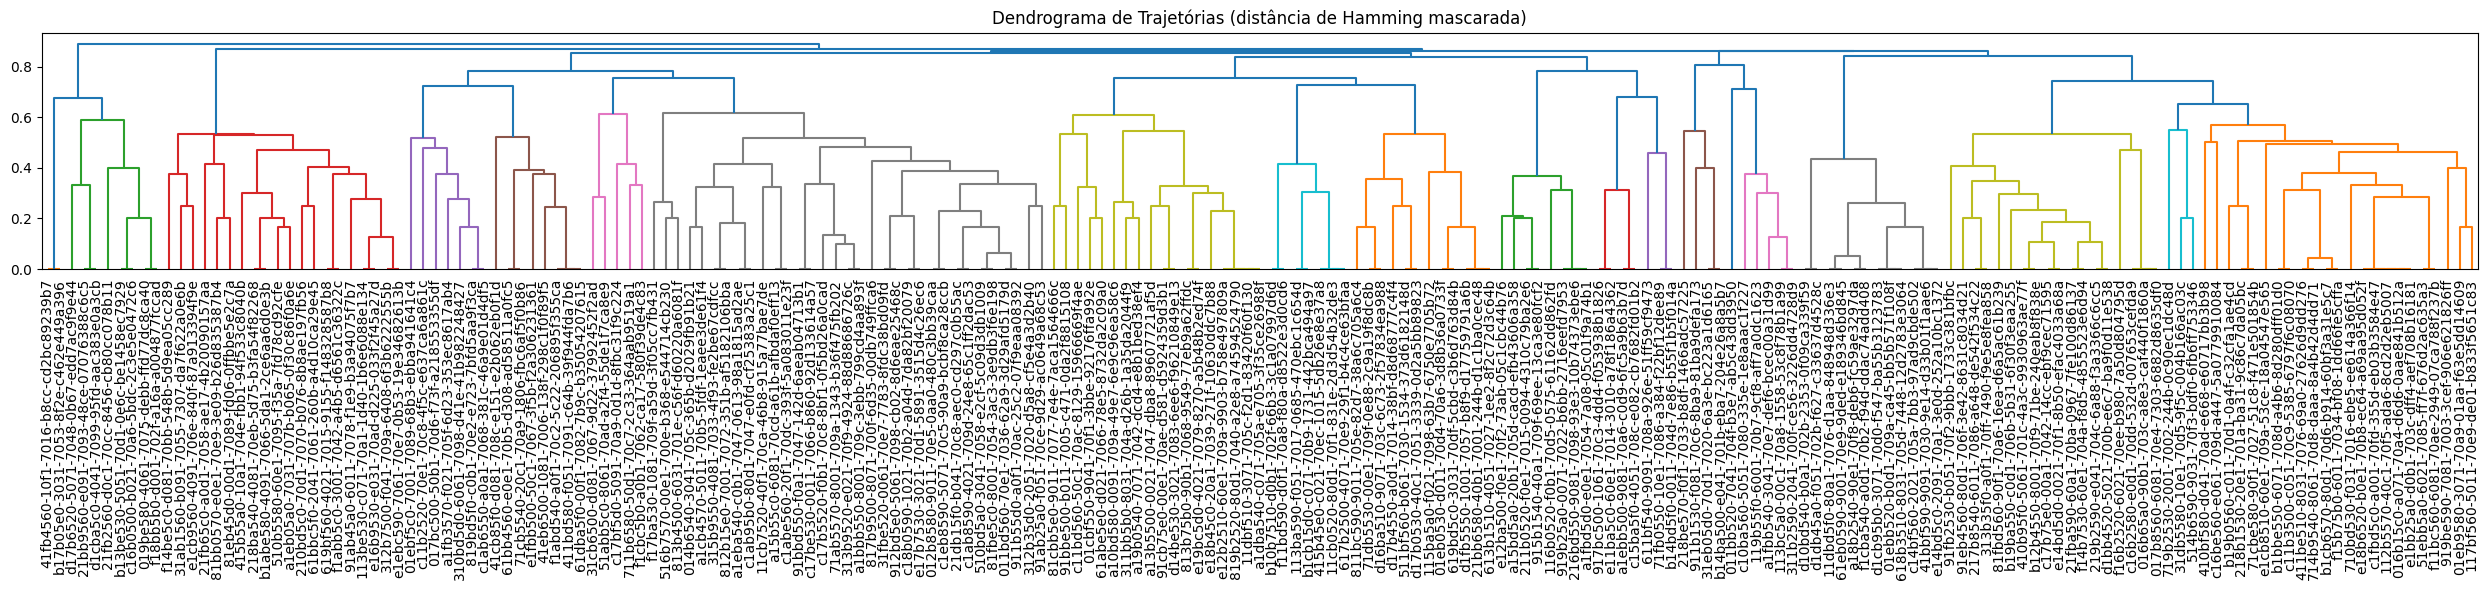

[Silhouette] best_k=8 com silhouette médio=0.2121


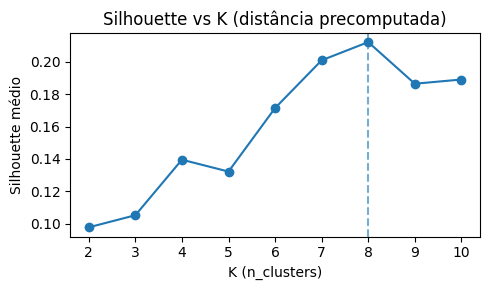

Grupos de trajetória salvos em: /Users/otacilio.maia/Desktop/studies/experimentosmestrado/helloworld/per_topic/trajetory/user_trajectory_groups.csv


NameError: name 'make_axes_locatable' is not defined

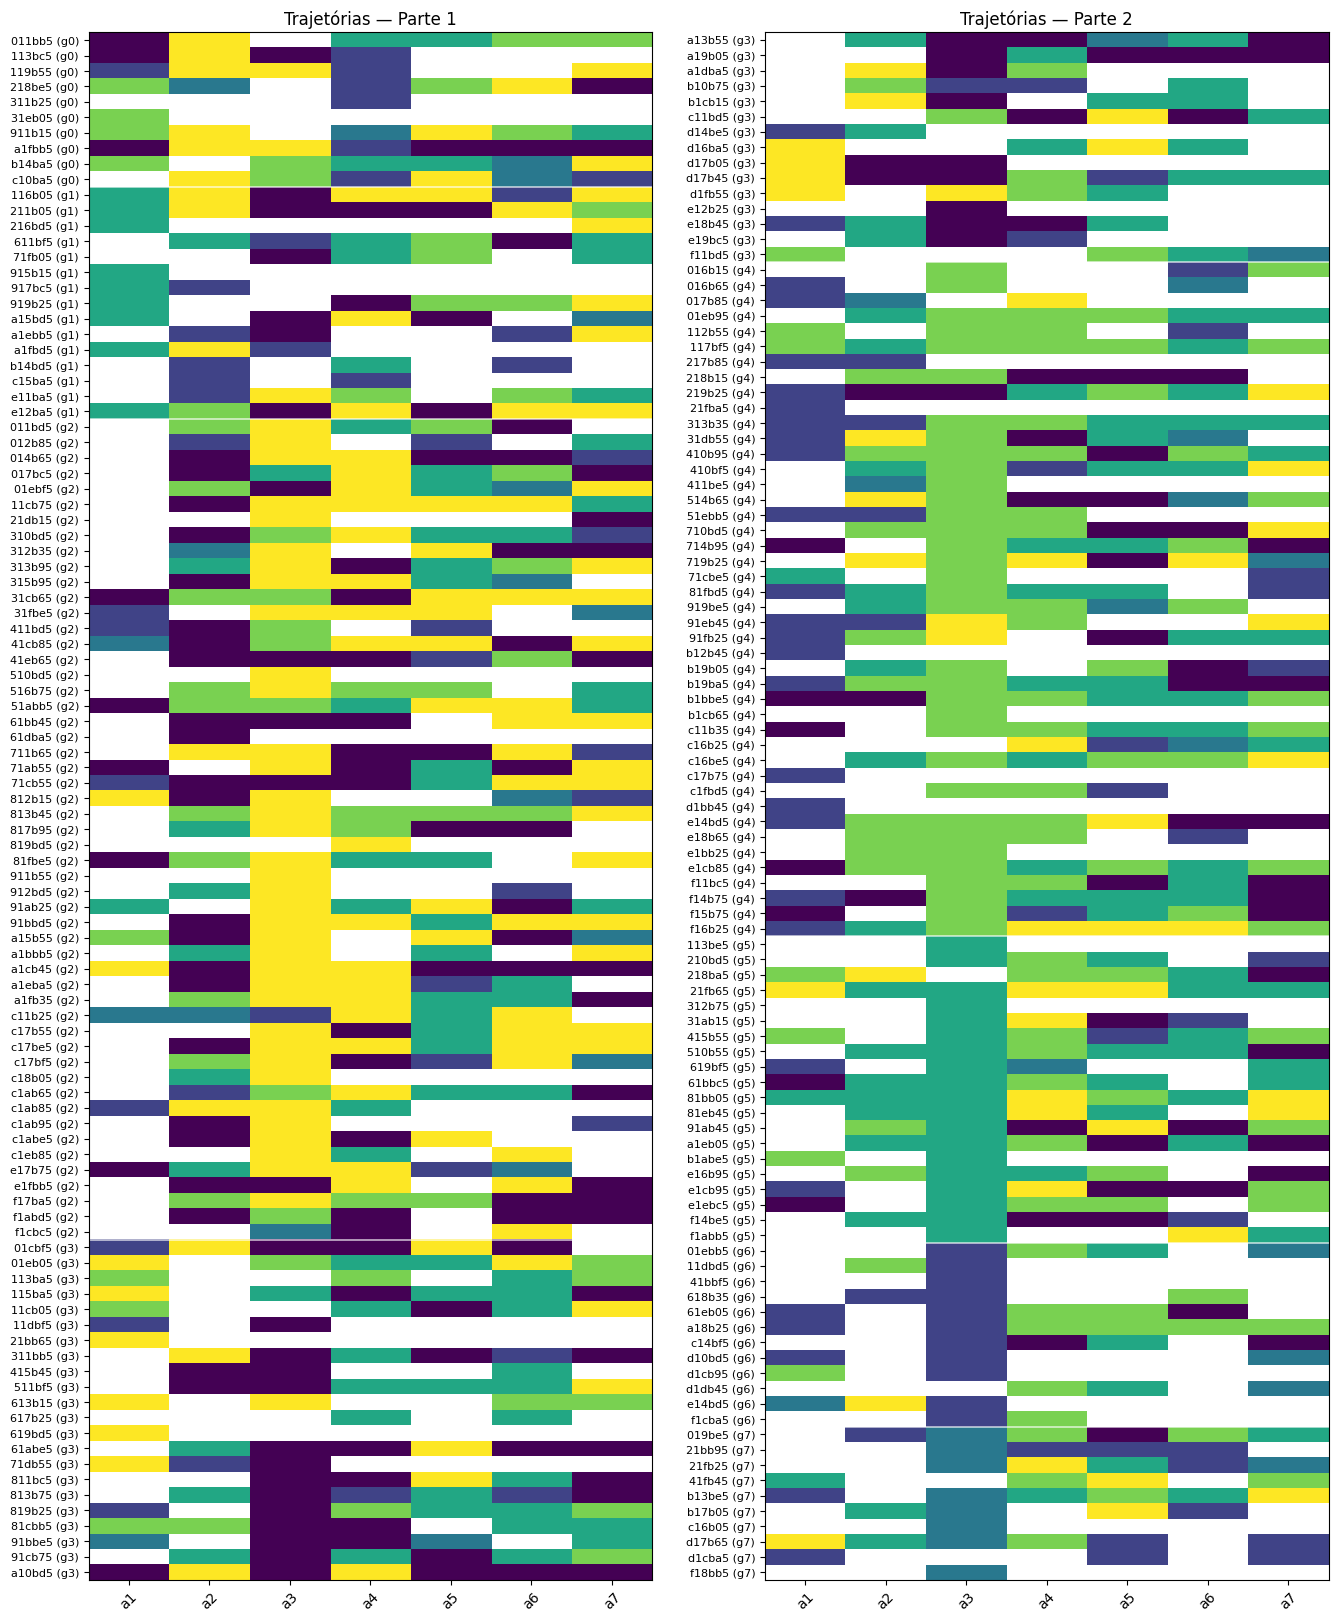

In [ ]:
# =======================
# 6) Distância entre trajetórias (Hamming mascarado), seleção de K e clustering
# =======================
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import warnings
from collections import Counter
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

def masked_hamming(u: np.ndarray, v: np.ndarray) -> float:
    mask = ~np.isnan(u) & ~np.isnan(v)
    if not np.any(mask):
        return 1.0
    return np.mean(u[mask] != v[mask])

X = traj.values.astype(float)
n = X.shape[0]

# 6.1) Matriz de distâncias
D = np.zeros((n, n), dtype=float)
for i in range(n):
    for j in range(i+1, n):
        d = masked_hamming(X[i], X[j])
        D[i, j] = D[j, i] = d

# 6.2) Dendrograma
if n >= 2:
    D_cond = squareform(D, checks=False)
    Z = linkage(D_cond, method=LINKAGE)
    plt.figure(figsize=(25, 6))
    dendrogram(Z, labels=traj.index.tolist(), leaf_rotation=90, leaf_font_size=10)
    plt.title("Dendrograma de Trajetórias (distância de Hamming mascarada)")
    plt.tight_layout()
    plt.show()
else:
    Z = None
    print("Conjunto de usuários insuficiente para dendrograma.")

# 6.3) Seleção de K por Silhouette
K_MIN = 2
K_MAX = min(10, n)
best_k, best_sil = None, -1.0
sil_curve = []

if n >= 3:
    for k in range(K_MIN, max(K_MIN+1, K_MAX+1)):
        agg_linkage_eval = LINKAGE if LINKAGE != "ward" else "average"
        agg_eval = AgglomerativeClustering(
            n_clusters=min(k, n),
            linkage=agg_linkage_eval,
            metric="precomputed"
        )
        labels_k = agg_eval.fit_predict(D)
        if len(np.unique(labels_k)) < 2:
            sil_curve.append(np.nan); continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                sil = silhouette_score(D, labels_k, metric="precomputed")
            except Exception:
                sil = np.nan
        sil_curve.append(sil)
        if np.isfinite(sil) and sil > best_sil:
            best_sil, best_k = sil, k
    if best_k is None:
        best_k = max(2, min(4, n))
        print(f"[Silhouette] Fallback best_k={best_k}")
    else:
        print(f"[Silhouette] best_k={best_k} com silhouette médio={best_sil:.4f}")
    ks = list(range(K_MIN, max(K_MIN+1, K_MAX+1)))
    plt.figure(figsize=(5,3)); plt.plot(ks, sil_curve, marker='o'); plt.axvline(best_k, ls='--', alpha=0.6)
    plt.title("Silhouette vs K (distância precomputada)"); plt.xlabel("K (n_clusters)"); plt.ylabel("Silhouette médio")
    plt.tight_layout(); plt.show()
else:
    best_k = max(2, min(4, n)); print(f"[Silhouette] Poucos usuários; usando best_k={best_k}")

# 6.4) Clustering final
if n >= 2:
    agg_linkage = LINKAGE
    if agg_linkage == "ward":
        print("Aviso: 'ward' não é compatível com matriz precomputada. Usando 'average'.")
        agg_linkage = "average"
    try:
        agg = AgglomerativeClustering(n_clusters=min(best_k, n), linkage=agg_linkage, metric="precomputed")
    except TypeError:
        agg = AgglomerativeClustering(n_clusters=min(best_k, n), linkage=agg_linkage, affinity="precomputed")
    cluster_labels = agg.fit_predict(D)
else:
    cluster_labels = np.zeros(n, dtype=int)

# 6.5) Cluster DF e Heatmap
# ============================================================
# 6.5) Heatmap reorganizado em duas colunas
# ============================================================

cluster_df = pd.DataFrame({
    "userId": traj.index,
    "trajectory_group": cluster_labels
}).set_index("userId")

groups_path = (OUT_DIR / "user_trajectory_groups.csv")
cluster_df.to_csv(groups_path)
print("Grupos de trajetória salvos em:", groups_path.resolve())

# Ordenação por grupo
order = np.lexsort((traj.index.values, cluster_labels))
traj_sorted = traj.iloc[order]
sorted_user_ids = traj.index.values[order]
sorted_groups = cluster_labels[order]

# Divide em duas metades
half = len(traj_sorted) // 2

traj_part1 = traj_sorted.iloc[:half]
uids_part1 = sorted_user_ids[:half]
groups_part1 = sorted_groups[:half]

traj_part2 = traj_sorted.iloc[half:]
uids_part2 = sorted_user_ids[half:]
groups_part2 = sorted_groups[half:]

# Prepara Y tick labels
yticks1 = [f"{str(uid)[:6]} (g{g})" for uid, g in zip(uids_part1, groups_part1)]
yticks2 = [f"{str(uid)[:6]} (g{g})" for uid, g in zip(uids_part2, groups_part2)]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, max(6, len(traj_sorted)*0.1)),
    sharex=True
)

# ---- Painel 1 ----
im1 = axes[0].imshow(traj_part1.values, aspect="auto", interpolation="nearest")
axes[0].set_title("Trajetórias — Parte 1")
axes[0].set_yticks(range(len(traj_part1)))
axes[0].set_yticklabels(yticks1, fontsize=8)
axes[0].set_xticks(range(len(TOPIC_ORDER)))
axes[0].set_xticklabels(TOPIC_ORDER, rotation=45)

boundaries1 = np.where(np.diff(groups_part1) != 0)[0]
for b in boundaries1:
    axes[0].axhline(b + 0.5, color='white', linewidth=1.2, alpha=0.7)

# ---- Painel 2 ----
im2 = axes[1].imshow(traj_part2.values, aspect="auto", interpolation="nearest")
axes[1].set_title("Trajetórias — Parte 2")
axes[1].set_yticks(range(len(traj_part2)))
axes[1].set_yticklabels(yticks2, fontsize=8)
axes[1].set_xticks(range(len(TOPIC_ORDER)))
axes[1].set_xticklabels(TOPIC_ORDER, rotation=45)

boundaries2 = np.where(np.diff(groups_part2) != 0)[0]
for b in boundaries2:
    axes[1].axhline(b + 0.5, color='white', linewidth=1.2, alpha=0.7)

# =================================================================
#  BARRA DE CORES AO LADO DIREITO (sem sobrepor)
# =================================================================
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="3%", pad=0.3)

cbar = fig.colorbar(im2, cax=cax)
cbar.set_label("Cluster", fontsize=10)

plt.tight_layout()

# Salvar
out_png = OUT_DIR / "user_trajectories_two_columns.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()

print("Heatmap 2-column salvo em:", out_png.resolve())

